In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("CH.SC.U4CSE24156_EX-8.6_2(SVM).csv")

print(data.shape)
data.head()

(20, 3)


,Word_Frequency,Message_Length,Spam
0,2,20,0
1,3,25,0
2,4,30,0
3,5,35,0
4,6,40,0


In [5]:
data.isnull().sum()

Word_Frequency    0
Message_Length    0
Spam              0
dtype: int64

In [7]:
X = data[
    [
        "Word_Frequency",
        "Message_Length"
    ]
].values

y = data["Spam"].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=5
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(14, 2)
(14,)
(6, 2)
(6,)


In [11]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [13]:
model = SVC(
    kernel='rbf',
    random_state=0
)

model.fit(X_train, y_train)

SVC(random_state=0)

In [15]:
svc_prediction = model.predict(X_test)

print("svc_prediction : ", svc_prediction)

svc_prediction :  [0 0 1 1 1 0]


In [17]:
conf_mat = metrics.confusion_matrix(
    y_test,
    svc_prediction
)

print("SVC [ kernel - rbf ]")
print("Confusion Matrix : \n", conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    svc_prediction
)

print("Accuracy Score : ", accuracy_score)

print(
    "Accuracy in Percentage : ",
    int(accuracy_score * 100),
    "%"
)

print(
    metrics.classification_report(
        svc_prediction,
        y_test
    )
)

SVC [ kernel - rbf ]
Confusion Matrix : 
 [[3 0]
 [0 3]]
Accuracy Score :  1.0
Accuracy in Percentage :  100 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



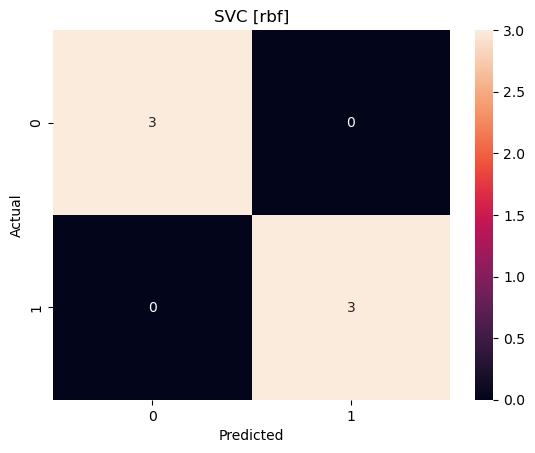

In [19]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(
    conf_mat,
    annot=True
).set(title='SVC [rbf]')

plt.show()

In [21]:
model = SVC(
    kernel='linear',
    random_state=0
)

model.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [23]:
svc_prediction = model.predict(X_test)

print("svc_prediction : ", svc_prediction)

svc_prediction :  [0 0 1 1 1 0]


In [25]:
conf_mat = metrics.confusion_matrix(
    y_test,
    svc_prediction
)

print("SVC [ kernel - linear ]")
print("Confusion Matrix : \n", conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    svc_prediction
)

print("Accuracy Score : ", accuracy_score)

print(
    "Accuracy in Percentage : ",
    int(accuracy_score * 100),
    "%"
)

print(
    metrics.classification_report(
        svc_prediction,
        y_test
    )
)

SVC [ kernel - linear ]
Confusion Matrix : 
 [[3 0]
 [0 3]]
Accuracy Score :  1.0
Accuracy in Percentage :  100 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



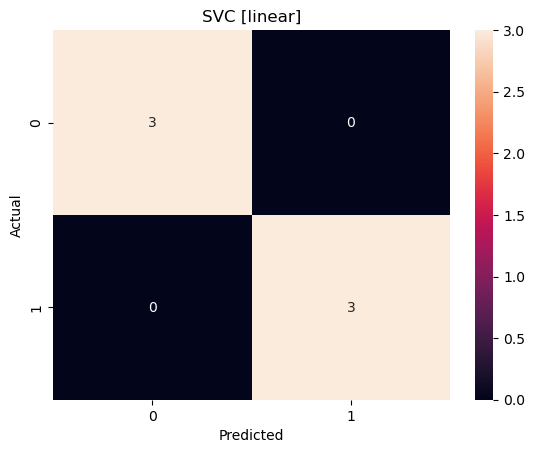

In [27]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(
    conf_mat,
    annot=True
).set(title='SVC [linear]')

plt.show()